In [1]:
#CamScanner
#Image transformation - translate, rotate, resize
#perspective

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [4]:
img = cv2.imread('alignment.jpg')
#print(img.shape)
#print(img.shape)

In [5]:
print(img.shape)

(474, 474, 3)


In [6]:
rows, cols = img.shape[:2]

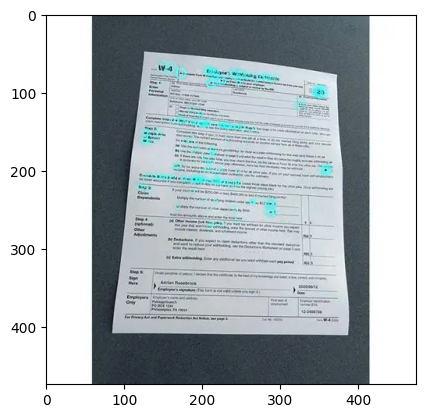

In [7]:
plt.imshow(img)
plt.show()

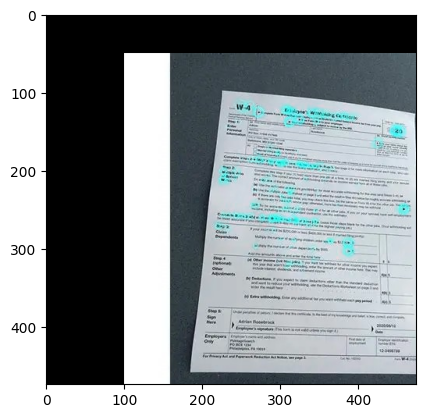

In [8]:
#create translation matrix
#format: [[1,0,tx],[0,1,ty]]
#tx- shift along x- axis(right)
#ty-shift along y-axis(down)
matrix = np.float32([[1,0,100],[0,1,50]])
translated = cv2.warpAffine(img, matrix,(cols,rows))
plt.imshow(translated)
plt.show()

In [9]:
#rotation
#define centre of rotation
center=(cols//2,rows//2)

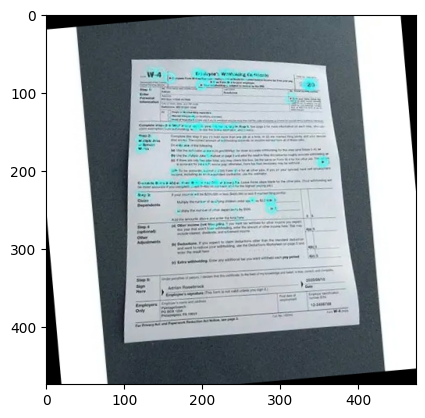

In [10]:
#Parameters:center,angle,scale
#angle: rotation in degrees (+ve=counter-clockwise)
#scale: zoom(1=same size)
matrix=cv2.getRotationMatrix2D(center,5,1)

#apply rotation
rotated=cv2.warpAffine(img,matrix, (rows,cols))
plt.imshow(rotated)
plt.show()

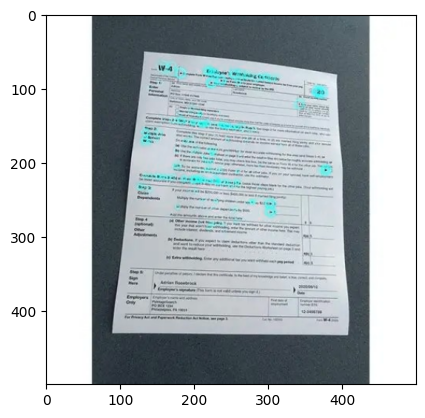

In [11]:
#Resize Image
#Parameters: (image, (width,height))
resized=cv2.resize(img, (500,500))
plt.imshow(resized)
plt.show()

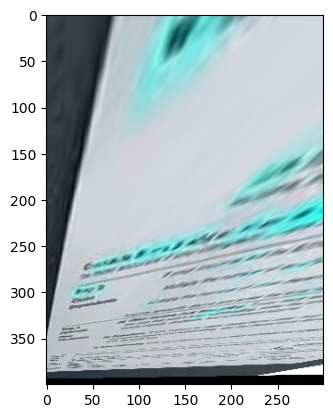

In [17]:
#Perspective Transform
#Concept: tilted document->top-down flat view
#format: define 4 source points (4 corners of document in original image)
#[top-left,top-right,bottom-right,bottom-left]

points1=np.float32([[100,150],[150,170],[550,550],[100,550]])
#define destination points
#create a perfect rectangle(flat-view)
points2=np.float32([[0,0],[300,0],[300,400],[0,400]])
matrix=cv2.getPerspectiveTransform(points1,points2)

#Apply perspective
warped=cv2.warpPerspective(img,matrix,(300,400)) 
plt.imshow(warped)
plt.show()

In [18]:
img=cv2.resize(img, (500,600))

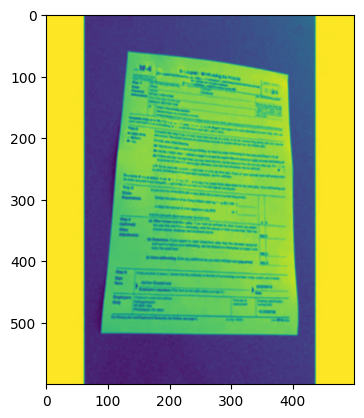

In [20]:
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#Apply Gaussian blur to remove noise
blur=cv2.GaussianBlur(gray,(5,5),0)
plt.imshow(blur)
plt.show() 


#Canny edge detection: to detect edges
#contours: list of detected shapes

edges=cv2.Canny(blur,5,150)
contours,_=cv2.findContours